In [1]:
# https://hal.science/hal-01890757/file/2018_ICIP_Jaouen.pdf

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [3]:
# Additive white Gaussian noise
def add_awgn(I, mean=0, sigma=30):
    gaussian = np.random.normal(mean, sigma, I.shape)
    noise_img = I + gaussian
    return np.clip(noise_img, 0.0, 255.0).astype(np.float32)

# https://www.geeksforgeeks.org/python/apply-a-gauss-filter-to-an-image-with-python/
# https://geekyisawesome.blogspot.com/2019/12/implementing-gaussian-blur-filter.html
# cv2.GaussianBlur()
def gaussian_kernel(size=3, sigma=30):
    kernel = np.zeros((size, size), dtype=np.float32)
    center = size // 2
    for i in range(size):
        for j in range(size):
            x = i - center
            y = j - center
            kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel /= np.sum(kernel)
    return kernel

# https://stackoverflow.com/questions/58477255/how-to-do-convolution-in-opencv
def degraded_image(I, size=3, sigma=30):
    kernel = gaussian_kernel(size, sigma)
    I_new = cv2.filter2D(I, -1, cv2.flip(kernel, -1), borderType=cv2.BORDER_REFLECT)  # convolution
    I_new = add_awgn(I_new, sigma=sigma)
    return I_new

# https://stackoverflow.com/questions/12729228/simple-efficient-bilinear-interpolation-of-images-in-numpy-and-python
def bilinear_interpolation(I, tau_u, tau_v):
    I_new = np.zeros_like(I, dtype=np.float32)
    h, w = I_new.shape[:2]
    
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    x = np.clip(x + tau_u, 0, w-1)
    y = np.clip(y + tau_v, 0, h-1)

    x0 = np.floor(x).astype(np.int32)
    y0 = np.floor(y).astype(np.int32)
    x1 = np.clip(x0 + 1, 0, w-1)
    y1 = np.clip(y0 + 1, 0, h-1)

    dx = x - x0
    dy = y - y0

    I_new = I[y0, x0] * (1 - dx) * (1 - dy)
    I_new += I[y0, x1] * dx * (1 - dy)
    I_new += I[y1, x0] * (1 - dx) * dy
    I_new += I[y1, x1] * dx * dy
    return I_new

# https://www.baeldung.com/cs/gradient-orientation-magnitude
# https://viblo.asia/p/tat-tan-tat-ve-object-detection-tu-cac-thuat-toan-co-ban-den-deep-learning-phan-1-n1j4l2NWLwl
# This is L2-norm of gradient vector
# Direction = arctan(G_y / G_x)
def gradient_magnitude(I):
    I_copy = I.copy().astype(np.float32)
    gradient_x = cv2.Sobel(I_copy, cv2.CV_32F, 1, 0, ksize=3)   # G_x = I(x+1, y) - I(x-1, y)
    gradient_y = cv2.Sobel(I_copy, cv2.CV_32F, 0, 1, ksize=3)   # G_y = I(x, y+1) - I(x, y-1)
    return np.sqrt(gradient_x**2 + gradient_y**2)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

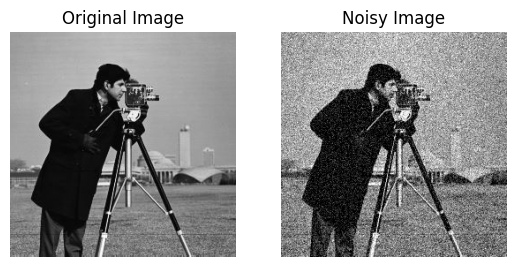

In [ ]:
img = cv2.imread('cameraman.jpg', cv2.IMREAD_GRAYSCALE)
if img is None: 
    raise ValueError("Fail to read image")
noise_img = add_awgn(img, sigma=30)

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Noisy Image")
plt.imshow(noise_img, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

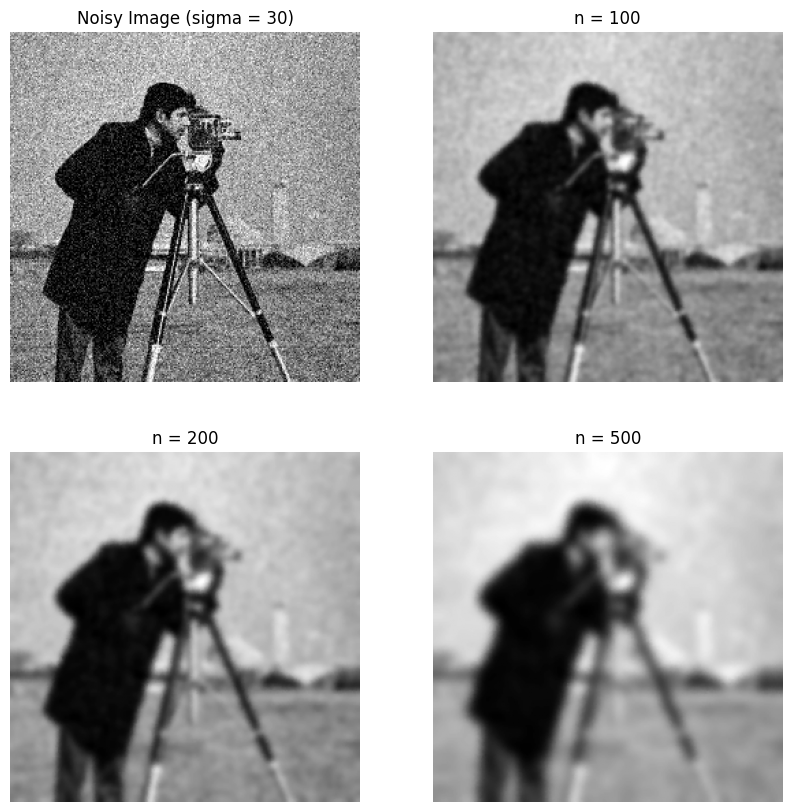

In [5]:
def linear_advection_filter(I, n=100, tau=0.05):
    I_copy = I.copy().astype(np.float32)
    h, w = I_copy.shape[:2]

    for _ in range(n):
        theta = np.random.uniform(0, 2 * np.pi, (h, w))
        u, v = np.cos(theta), np.sin(theta)
        tau_u = tau * u
        tau_v = tau * v
        I_copy = bilinear_interpolation(I_copy, tau_u, tau_v)
        I_copy = np.clip(I_copy, 0, 255)
    return I_copy.astype(np.uint8)


plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.title("Noisy Image (sigma = 30)")
plt.imshow(noise_img, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("n = 100")
LAF_100 = linear_advection_filter(noise_img, n=100, tau=0.05)
plt.imshow(LAF_100, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("n = 200")
LAF_200 = linear_advection_filter(noise_img, n=200, tau=0.05)
plt.imshow(LAF_200, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("n = 500")
LAF_500 = linear_advection_filter(noise_img, n=500, tau=0.05)
plt.imshow(LAF_500, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

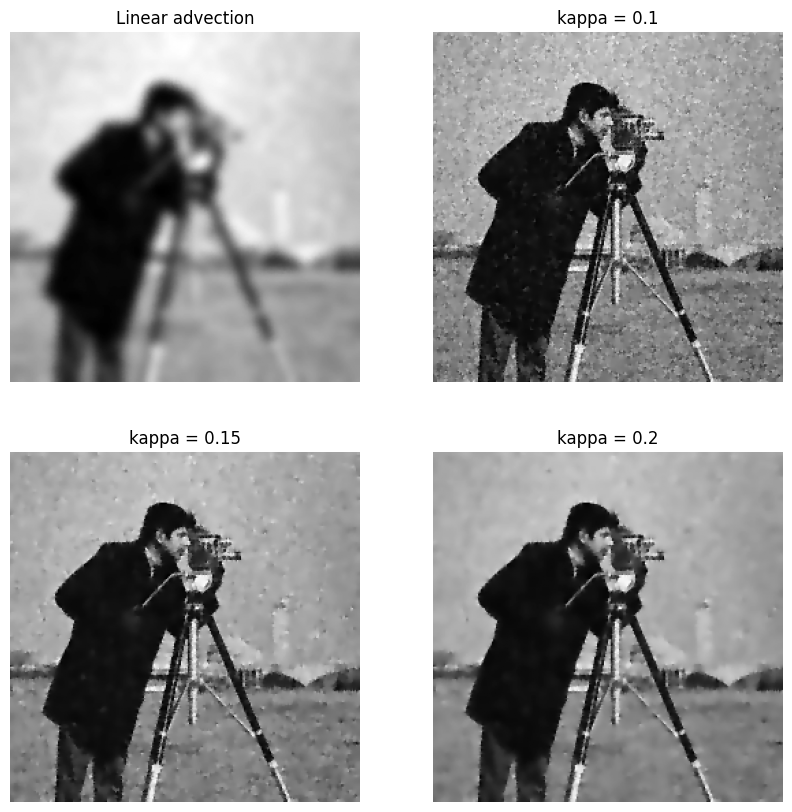

In [6]:
def nonlinear_advection_filter(I, n=200, tau=0.1, kappa=0.1, rho=0):
    I_copy = I.copy().astype(np.float32) / 255.0
    h, w = I_copy.shape[:2]

    for _ in range(n):
        theta = np.random.uniform(0, 2 * np.pi, (h, w))
        u, v = np.cos(theta), np.sin(theta)
        
        I_smoothed = gaussian_filter(I_copy, sigma=rho)
        delta_I = gradient_magnitude(I_smoothed)

        tau_i = tau / (1 + (delta_I / kappa)**2)     # Must be base [0, 1] to minimize the value
        tau_u = tau_i * u
        tau_v = tau_i * v

        I_copy = bilinear_interpolation(I_copy, tau_u, tau_v)
        I_copy = np.clip(I_copy, 0.0, 1.0)
    return np.clip(I_copy * 255, 0, 255).astype(np.uint8)


plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.title("Linear advection")
plt.imshow(LAF_500, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("kappa = 0.1")
NAF_1 = nonlinear_advection_filter(noise_img, kappa=0.1)
plt.imshow(NAF_1, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("kappa = 0.15")
NAF_2 = nonlinear_advection_filter(noise_img, kappa=0.15)
plt.imshow(NAF_2, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("kappa = 0.2")
NAF_3 = nonlinear_advection_filter(noise_img, kappa=0.2)
plt.imshow(NAF_3, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

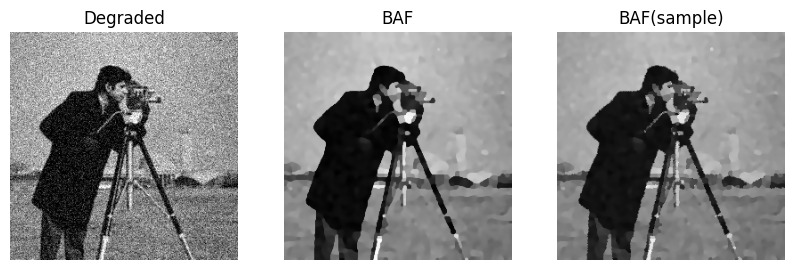

In [7]:
def external_field(gradient):
    x_conv, y_conv = np.meshgrid(np.linspace(-1, 1, 3), np.linspace(-1, 1, 3))
    r = np.sqrt(x_conv ** 2 + y_conv ** 2)
    r[1][1] = 1    
    x_conv /= -r    
    y_conv /= -r

    u_f = cv2.filter2D(gradient, cv2.CV_32F, x_conv)
    v_f = cv2.filter2D(gradient, cv2.CV_32F, y_conv)

    return u_f, v_f

def BAF_func(image, n=250, tau=0.05, kappa=0.5, rho=0):
    I = image.astype(np.float32) / 255.0
    h, w = I.shape[:2]

    for _ in range(n):
        theta = np.random.uniform(0, 2 * np.pi, (h, w))

        I_smoothed = gaussian_filter(I, sigma=rho)
        delta_I = gradient_magnitude(I_smoothed)

        tau_i = tau / (1 + (delta_I / kappa) ** 2)

        u_f, v_f = external_field(delta_I)
        u = np.cos(theta) + u_f
        v = np.sin(theta) + v_f

        dx = tau_i * u
        dy = tau_i * v

        map_x, map_y = np.meshgrid(np.arange(w), np.arange(h))
        map_x = np.clip(map_x + dx, 0, w - 1).astype(np.float32)
        map_y = np.clip(map_y + dy, 0, h - 1).astype(np.float32)

        I = cv2.remap(I, map_x, map_y, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

    I = np.clip(I * 255.0, 0, 255).astype(np.uint8)
    return I

# ----------------------------------------------------------------------------------------------------------


def biased_advection_filter(I, n=250, tau=0.05, kappa=0.5, rho=0):
    I_copy = I.copy().astype(np.float32) / 255.0
    h, w = I_copy.shape[:2]

    for _ in range(n):
        theta = np.random.uniform(0, 2 * np.pi, (h, w))
        
        I_smoothed = gaussian_filter(I_copy, sigma=rho)
        delta_I = gradient_magnitude(I_smoothed)

        tau_i = tau / (1 + (delta_I / kappa)**2)     # Must be base [0, 1] to minimize the value

        u_f, v_f = external_field(delta_I)
        u = np.cos(theta) + u_f
        v = np.sin(theta) + v_f

        tau_u = tau_i * u
        tau_v = tau_i * v

        I_copy = bilinear_interpolation(I_copy, tau_u, tau_v)
        I_copy = np.clip(I_copy, 0.0, 1.0)

    return np.clip(I_copy * 255, 0, 255).astype(np.uint8)


degraded = degraded_image(img, size=2, sigma=30)

plt.figure(figsize=(10, 10))

plt.subplot(1, 3, 1)
plt.title("Degraded")
plt.imshow(degraded, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("BAF")
BAF = biased_advection_filter(degraded, n=250, tau=0.05, kappa=0.5, rho=0)
plt.imshow(BAF, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("BAF(sample)")
BAF_sample = BAF_func(degraded, n=250, tau=0.05, kappa=0.5, rho=0)
plt.imshow(BAF_sample, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

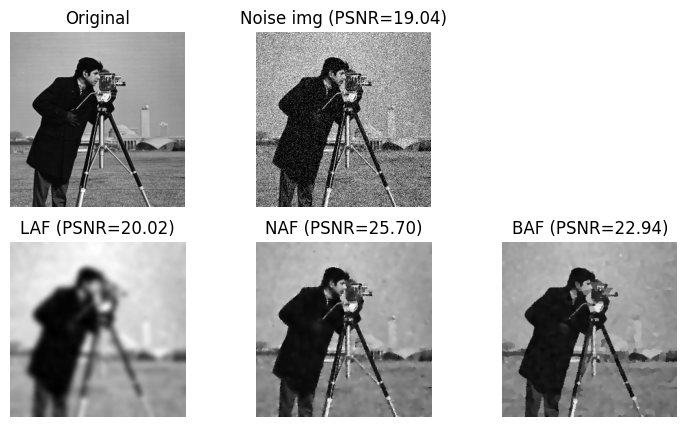

In [8]:
# https://viblo.asia/p/cac-chi-so-danh-gia-duoc-su-dung-cho-bai-toan-image-generation-is-fid-psnr-ssim-XL6lA0zDZek
def psnr(Original, Noise):
    Original = Original.astype(np.float32)
    Noise = Noise.astype(np.float32)
    MSE = np.mean((Original - Noise)**2)
    if (MSE == 0): return 100   # No noise
    MAX_I = 255
    return 10 * np.log10(MAX_I**2 / MSE)

# print('Noise image:', psnr(img, noise_img))
# print('LAF500:', psnr(img, LAF_500))
# print('NAF:', psnr(img, NAF_3))
# print('Degraded:', psnr(img, degraded))
# print('BAF:', psnr(img, BAF))
# print('BAF_sample:', psnr(img, BAF_sample))


plt.figure(figsize=(9, 5))

plt.subplot(2, 3, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title(f"Noise img (PSNR={psnr(img, noise_img):.2f})")
plt.imshow(noise_img, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title(f"LAF (PSNR={psnr(img, LAF_500):.2f})")
plt.imshow(LAF_500, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title(f"NAF (PSNR={psnr(img, NAF_3):.2f})")
plt.imshow(NAF_3, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title(f"BAF (PSNR={psnr(img, BAF_sample):.2f})")
plt.imshow(BAF_sample, cmap='gray')
plt.axis('off')

# plt.subplot(2, 3, 4)
# plt.title("BAF(sample)")
# BAF_sample = BAF_func(degraded, n=250, tau=0.05, kappa=0.5, rho=0)
# plt.imshow(BAF_sample, cmap='gray')
# plt.axis('off')